In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from pathlib import Path

print("Python-библиотеки загружены")
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

for name in ["adult.data.txt", "adult.test.txt", "adult.names.txt"]:
    print(name, "—", "найден" if Path(name).exists() else "НЕ НАЙДЕН")

Python-библиотеки загружены
Pandas: 3.0.6
Scikit-learn: 1.9.1
adult.data.txt — найден
adult.test.txt — найден
adult.names.txt — найден


In [3]:
import pandas as pd

columns = [
    "age", "workclass", "fnlwgt", "education",
    "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain",
    "capital_loss", "hours_per_week", "native_country",
    "income"
]

train = pd.read_csv(
    "adult.data.txt",
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

test = pd.read_csv(
    "adult.test.txt",
    names=columns,
    skiprows=1,
    skipinitialspace=True,
    na_values="?"
)

train["income"] = train["income"].str.strip()
test["income"] = test["income"].str.strip().str.rstrip(".")

print("Обучающая выборка:", train.shape)
print("Тестовая выборка:", test.shape)

print("\nРаспределение классов:")
print(train["income"].value_counts())

print("\nКоличество пропусков:", train.isna().sum().sum())

Обучающая выборка: (32561, 15)
Тестовая выборка: (16281, 15)

Распределение классов:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Количество пропусков: 4262


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X_train = train.drop(columns="income")
y_train = train["income"]

X_test = test.drop(columns="income")
y_test = test["income"]

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numeric_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Подготовка завершена")
print("Обучающая выборка:", X_train_ready.shape)
print("Тестовая выборка:", X_test_ready.shape)

Подготовка завершена
Обучающая выборка: (32561, 105)
Тестовая выборка: (16281, 105)


In [5]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

n_estimators_values = [50, 60, 70, 80, 90, 100]
experiment_results = []

for n in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n,
        criterion="gini",
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )

    start = time.perf_counter()
    model.fit(X_train_ready, y_train)
    predictions = model.predict(X_test_ready)
    elapsed = time.perf_counter() - start

    experiment_results.append({
        "trees": n,
        "time_sec": elapsed,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(
            y_test, predictions,
            pos_label=">50K",
            zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions,
            pos_label=">50K",
            zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions,
            pos_label=">50K",
            zero_division=0
        )
    })

    print(f"Готово: {n} деревьев, время {elapsed:.2f} с")

results_df = pd.DataFrame(experiment_results)

print("\nРезультаты экспериментов:")
display(results_df.round(4))

results_df.to_csv(
    "ensemble_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Результаты сохранены в ensemble_results.csv")

Готово: 50 деревьев, время 0.66 с
Готово: 60 деревьев, время 0.80 с
Готово: 70 деревьев, время 0.81 с
Готово: 80 деревьев, время 1.01 с
Готово: 90 деревьев, время 1.02 с
Готово: 100 деревьев, время 1.15 с

Результаты экспериментов:


,trees,time_sec,accuracy,precision,recall,f1
0,50,0.6579,0.8363,0.7854,0.4225,0.5495
1,60,0.8000,0.8364,0.7940,0.4150,0.5451
2,70,0.8148,0.8367,0.7923,0.4186,0.5478
3,80,1.0068,0.8386,0.7889,0.4324,0.5586
4,90,1.0187,0.8377,0.7927,0.4236,0.5521
5,100,1.1457,0.8383,0.7901,0.4295,0.5565


Результаты сохранены в ensemble_results.csv


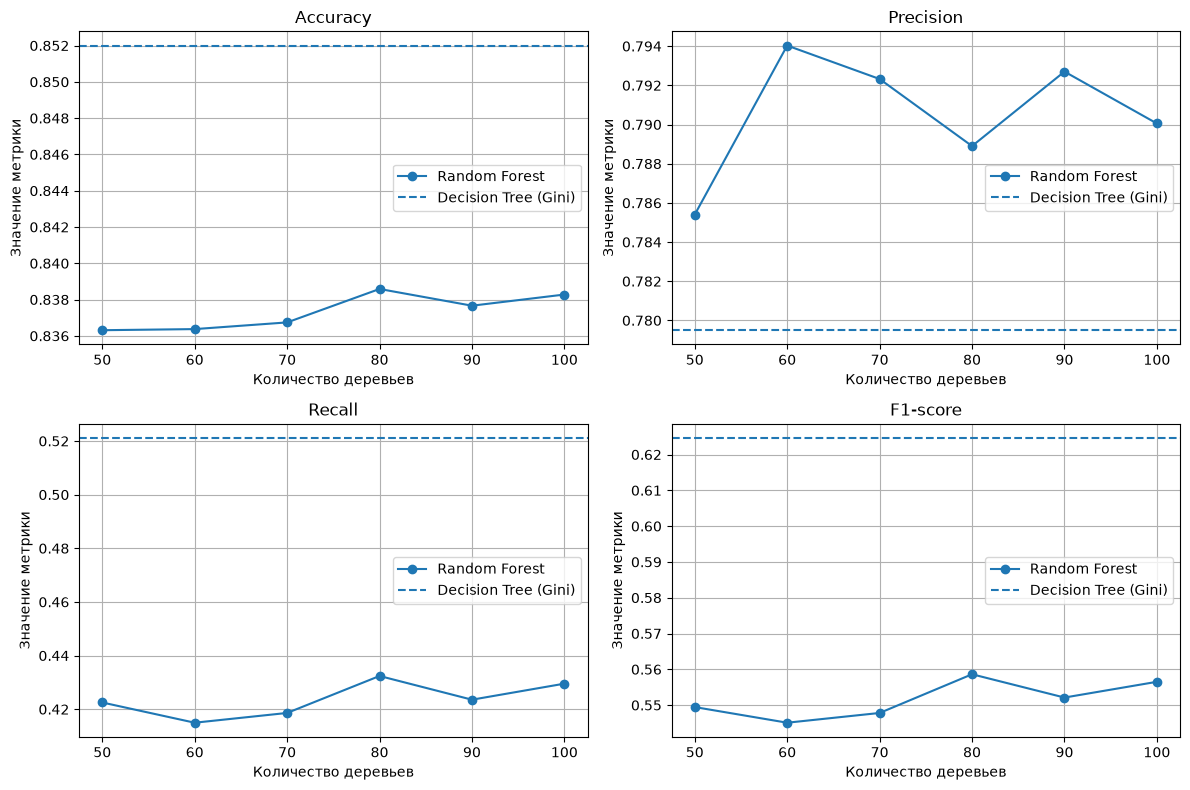

График сохранён в ensemble_comparison.png


In [6]:
import matplotlib.pyplot as plt

# Результаты дерева решений из предыдущей практической работы
tree_metrics = {
    "accuracy": 0.8520,
    "precision": 0.7795,
    "recall": 0.5211,
    "f1": 0.6246
}

metrics = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics.items()):
    ax.plot(
        results_df["trees"],
        results_df[metric],
        marker="o",
        label="Random Forest"
    )

    ax.axhline(
        y=tree_metrics[metric],
        linestyle="--",
        label="Decision Tree (Gini)"
    )

    ax.set_title(title)
    ax.set_xlabel("Количество деревьев")
    ax.set_ylabel("Значение метрики")
    ax.set_xticks(results_df["trees"])
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig("ensemble_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("График сохранён в ensemble_comparison.png")